In [1]:
import numpy as np
import pandas as pd

ca_meta = pd.read_csv('../ca/ca_meta.csv')
sd_meta = ca_meta[ca_meta.District == 11]
sd_meta = sd_meta.reset_index()
sd_meta = sd_meta.drop(columns=['index'])
sd_meta.to_csv('sd_meta.csv', index=False)
print(sd_meta[sd_meta.duplicated(subset=['Lat', 'Lng'])])
sd_meta

Empty DataFrame
Columns: [ID, Lat, Lng, District, County, Fwy, Lanes, Type, Direction, ID2]
Index: []


,ID,Lat,Lng,District,County,Fwy,Lanes,Type,Direction,ID2
0,1114091,32.544463,-117.032486,11,San Diego,I5-N,6,Mainline,N,6931
1,1118333,32.551690,-117.045725,11,San Diego,I5-N,4,Mainline,N,6932
2,1118348,32.558459,-117.061845,11,San Diego,I5-N,4,Mainline,N,6933
3,1114720,32.561334,-117.067081,11,San Diego,I5-N,4,Mainline,N,6934
4,1118352,32.569052,-117.076507,11,San Diego,I5-N,4,Mainline,N,6935
...,...,...,...,...,...,...,...,...,...,...
711,1123276,32.564373,-116.969279,11,San Diego,I905-W,3,Mainline,W,7642
712,1122394,32.564336,-116.961909,11,San Diego,I905-W,3,Mainline,W,7643
713,1123261,32.564112,-116.950744,11,San Diego,I905-W,3,Mainline,W,7644
714,1123256,32.560935,-116.944559,11,San Diego,I905-W,3,Mainline,W,7645


In [2]:
sd_meta_id2 = sd_meta.ID2.values.tolist()
print(len(sd_meta_id2))

ca_rn_adj = np.load('../ca/ca_rn_adj.npy')
print(ca_rn_adj.shape)

sd_rn_adj = ca_rn_adj[sd_meta_id2]
sd_rn_adj = sd_rn_adj[:,sd_meta_id2]
print(sd_rn_adj.shape)

np.save('sd_rn_adj.npy', sd_rn_adj)

716
(8600, 8600)
(716, 716)


In [1]:
year = ''  # please specify the year, our experiments use 2019

sd_meta.ID = sd_meta.ID.astype(str)
sd_meta_id = sd_meta.ID.values.tolist()

ca_his = pd.read_hdf('../ca/ca_his_' + year +'.h5')
sd_his = ca_his[sd_meta_id]
sd_his

In [2]:
sd_his.to_hdf('sd_his_' + year + '.h5', key='t', mode='w')
sd_his.shape

In [3]:
# code for checking adj stat
sd_rn_adj = np.load('sd_rn_adj.npy')
node_num = sd_rn_adj.shape[0]

print(sd_rn_adj[0,0])
sd_rn_adj[np.arange(node_num), np.arange(node_num)] = 0
print(sd_rn_adj[0,0])

print('edge number', np.count_nonzero(sd_rn_adj))
print('node degree', np.mean(np.count_nonzero(sd_rn_adj, axis=-1)))
print('sparsity', np.count_nonzero(sd_rn_adj) / (node_num**2) * 100)

In [4]:
for year in ['raw_2017', 'raw_2018', 'raw_2019', 'raw_2020', 'raw_2021']:
    sd_meta.ID = sd_meta.ID.astype(str)
    gla_meta_id = sd_meta.ID.values.tolist()

    ca_his = pd.read_hdf('../ca/df/ca_his_' + year +'.h5')
    gla_his = ca_his[gla_meta_id]
    gla_his
    gla_his.to_hdf('sd_his_' + year + '.h5', key='t', mode='w')
    print(gla_his.shape)
    # code for checking adj stat
    gla_rn_adj = np.load('sd_rn_adj.npy')
    node_num = gla_rn_adj.shape[0]

    print(gla_rn_adj[0,0])
    gla_rn_adj[np.arange(node_num), np.arange(node_num)] = 0
    print(gla_rn_adj[0,0])

    print('edge number', np.count_nonzero(gla_rn_adj))
    print('node degree', np.mean(np.count_nonzero(gla_rn_adj, axis=-1)))
    print('sparsity', np.count_nonzero(gla_rn_adj) / (node_num**2) * 100)

(105120, 716)
1.0
0.0
edge number 17319
node degree 24.18854748603352
sparsity 3.378288755032614
(105120, 716)
1.0
0.0
edge number 17319
node degree 24.18854748603352
sparsity 3.378288755032614
(105120, 716)
1.0
0.0
edge number 17319
node degree 24.18854748603352
sparsity 3.378288755032614
(105408, 716)
1.0
0.0
edge number 17319
node degree 24.18854748603352
sparsity 3.378288755032614
(105120, 716)
1.0
0.0
edge number 17319
node degree 24.18854748603352
sparsity 3.378288755032614


In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [6]:
def plot_time_series(df, columns, layout=(2, 2), figsize=(20, 12), suptitle='Trends Over Time'):
    """
    Plots trends of time series data in specified layout of subplots.

    Parameters:
    - df: A pandas DataFrame containing the time series data.
    - columns: List of column names to plot.
    - layout: Layout of subplots, format as (rows, cols).
    - figsize: Size of the entire chart, format as (width, height).
    - suptitle: Overall title of the chart.
    """
    rows, cols = layout
    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    axs = axs.flatten()  # Flatten the array for easy iteration

    # Plot the time series graph for each specified column
    for i, column in enumerate(columns):
        if i >= len(axs):  # If the number of columns exceeds the number of subplots, break the loop
            break
        df[column].plot(ax=axs[i], title=f'Trends of {column} Over Time')
        axs[i].set_ylabel(column)
        axs[i].grid(True)

    # Hide any unused subplots
    for ax in axs[len(columns):]:
        ax.set_visible(False)

    plt.suptitle(suptitle)
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for the suptitle
    plt.show()

# Example usage
# Assuming your DataFrame is named national_illness, and you wish to plot the column 'ILITOTAL',
# you could call the function like this: plot_time_series(national_illness, ['ILITOTAL'], layout=(2, 3))

In [8]:
gla_his

,1114091,1118333,1118348,1114720,1118352,1118743,1120362,1118796,1118735,1118450,...,1125829,1125348,1125353,1125359,1123287,1123276,1122394,1123261,1123256,1122412
Time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,49.0,25.0,16.0,11.0,12.0,68.0,50.0,71.0,38.0,59.0,...,NaN,14.0,38.0,46.0,8.0,29.0,NaN,1.0,NaN,27.0
2021-01-01 00:05:00,41.0,24.0,30.0,37.0,28.0,58.0,44.0,71.0,34.0,54.0,...,NaN,17.0,34.0,37.0,8.0,35.0,NaN,3.0,NaN,31.0
2021-01-01 00:10:00,26.0,13.0,13.0,14.0,19.0,62.0,25.0,123.0,67.0,105.0,...,NaN,9.0,29.0,32.0,6.0,32.0,NaN,7.0,NaN,29.0
2021-01-01 00:15:00,35.0,14.0,16.0,22.0,23.0,57.0,28.0,119.0,66.0,93.0,...,NaN,10.0,26.0,31.0,5.0,34.0,NaN,3.0,NaN,30.0
2021-01-01 00:20:00,38.0,11.0,12.0,29.0,22.0,59.0,36.0,124.0,76.0,105.0,...,NaN,12.0,26.0,32.0,4.0,31.0,NaN,3.0,NaN,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 23:35:00,49.0,25.0,26.0,51.0,48.0,66.0,104.0,103.0,69.0,67.0,...,NaN,35.0,34.0,80.0,20.0,46.0,NaN,16.0,NaN,45.0
2021-12-31 23:40:00,43.0,25.0,29.0,51.0,68.0,110.0,133.0,123.0,77.0,105.0,...,NaN,40.0,44.0,63.0,21.0,45.0,NaN,14.0,NaN,43.0
2021-12-31 23:45:00,42.0,20.0,20.0,47.0,60.0,85.0,128.0,105.0,73.0,74.0,...,NaN,24.0,25.0,45.0,18.0,46.0,NaN,15.0,NaN,42.0


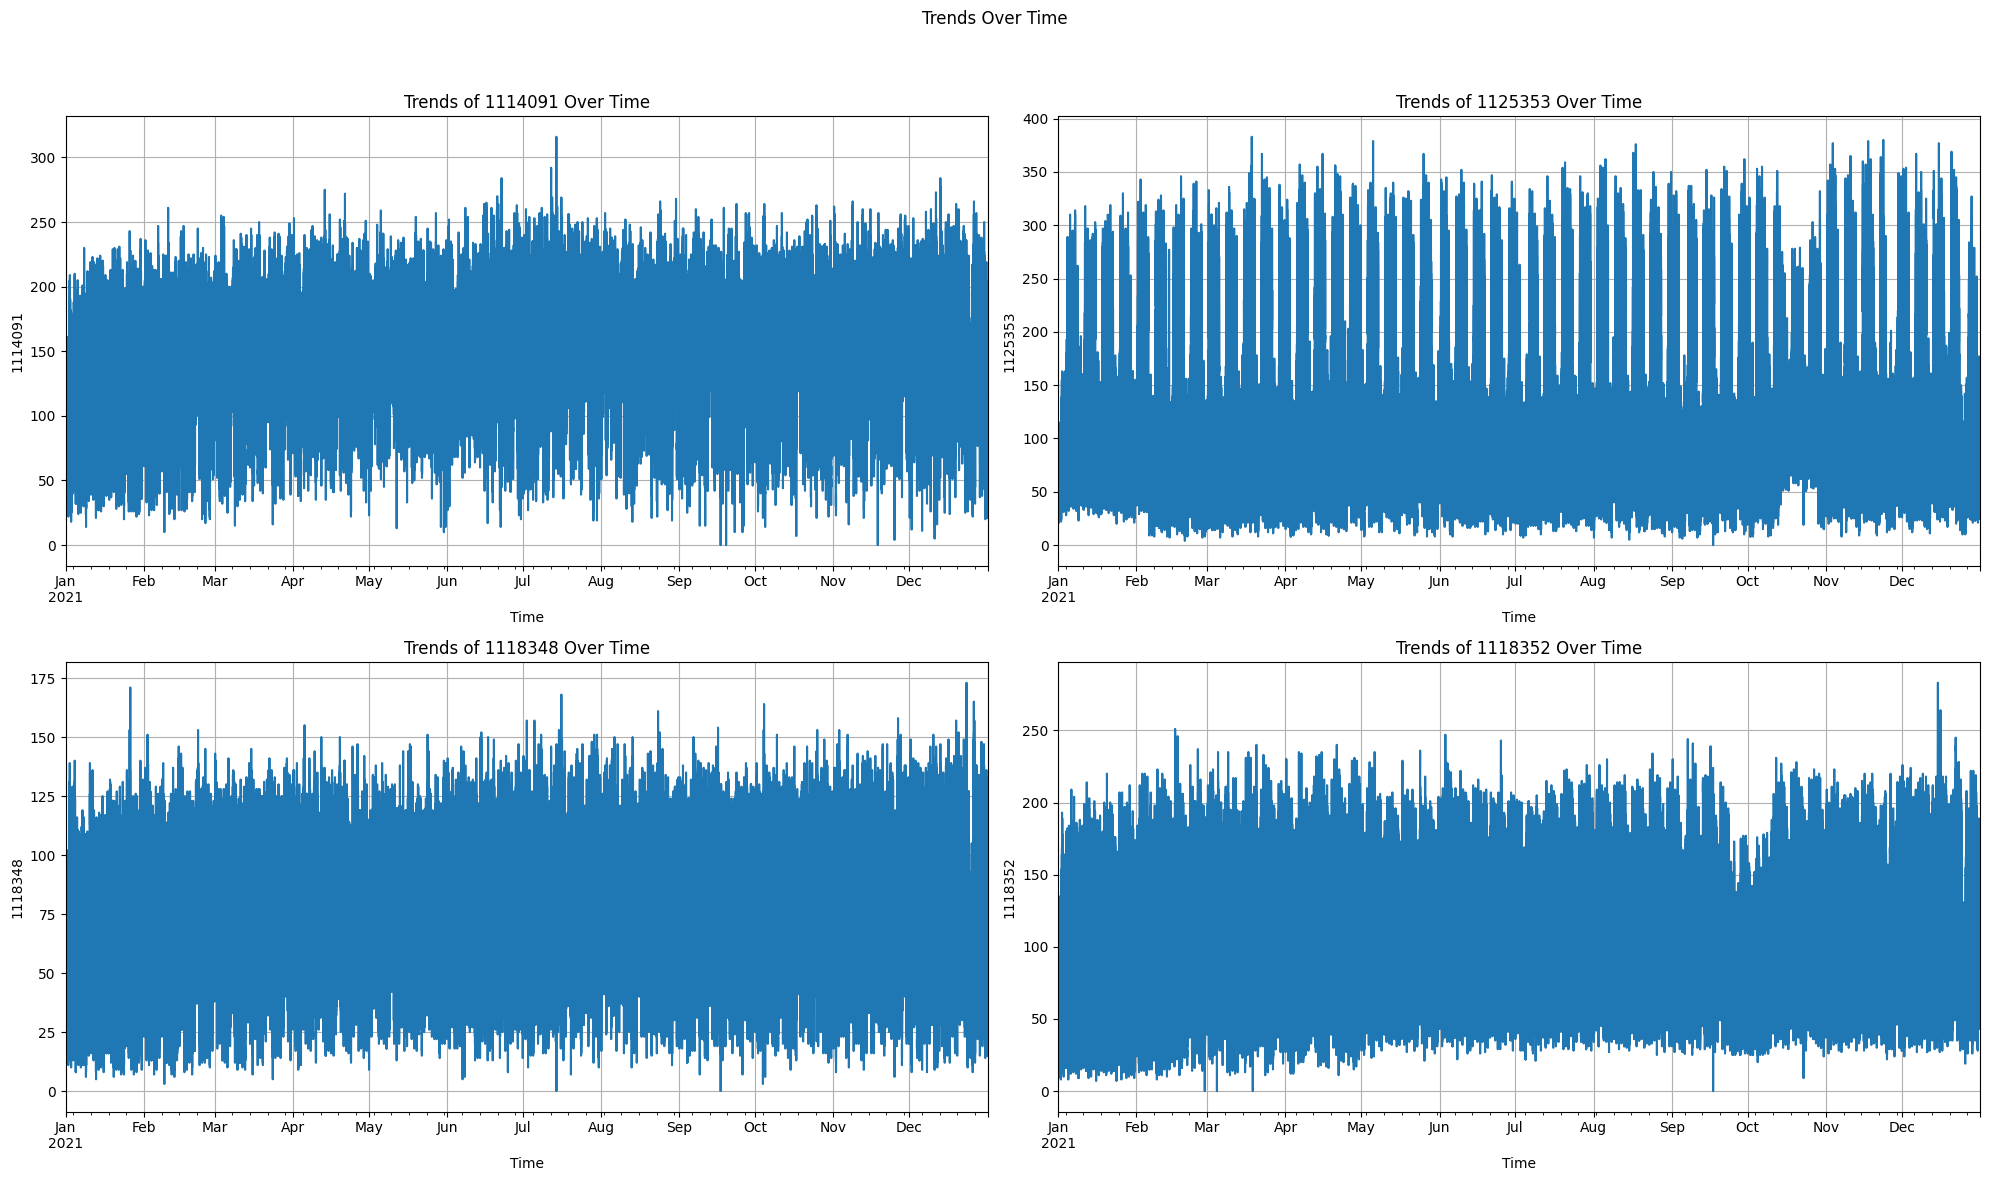

In [9]:
plot_time_series(gla_his, ['1114091', '1125353', '1118348', '1118352'],  layout=(2, 2))

In [10]:
# One-liner to get list of columns with all NaN
nan_columns = gla_his.columns[gla_his.isna().all()].tolist()
print(nan_columns)

['1118458', '1123086', '1123087', '1119865', '1119871', '1118442', '1122601', '1119653', '1115348', '1121722', '1115356', '1111551', '1115420', '1116593', '1116594', '1115528', '1115517', '1111552', '1108676', '1125879', '1114177', '1113641', '1118989', '1108299', '1108323', '1126361', '1121288', '1123089', '1125913', '1125912', '1123088', '1123081', '1123084', '1120040', '1111545', '1123072', '1123064', '1123069', '1123265', '1122380', '1125829', '1122394', '1123256']


In [11]:
gla_his = gla_his.dropna(axis=1, how='all')

In [12]:
gla_his

,1114091,1118333,1118348,1114720,1118352,1118743,1120362,1118796,1118735,1118450,...,1123282,1123270,1126526,1125348,1125353,1125359,1123287,1123276,1123261,1122412
Time,,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,49.0,25.0,16.0,11.0,12.0,68.0,50.0,71.0,38.0,59.0,...,176.0,81.0,2.0,14.0,38.0,46.0,8.0,29.0,1.0,27.0
2021-01-01 00:05:00,41.0,24.0,30.0,37.0,28.0,58.0,44.0,71.0,34.0,54.0,...,240.0,111.0,6.0,17.0,34.0,37.0,8.0,35.0,3.0,31.0
2021-01-01 00:10:00,26.0,13.0,13.0,14.0,19.0,62.0,25.0,123.0,67.0,105.0,...,205.0,95.0,7.0,9.0,29.0,32.0,6.0,32.0,7.0,29.0
2021-01-01 00:15:00,35.0,14.0,16.0,22.0,23.0,57.0,28.0,119.0,66.0,93.0,...,155.0,72.0,3.0,10.0,26.0,31.0,5.0,34.0,3.0,30.0
2021-01-01 00:20:00,38.0,11.0,12.0,29.0,22.0,59.0,36.0,124.0,76.0,105.0,...,237.0,12.0,4.0,12.0,26.0,32.0,4.0,31.0,3.0,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-31 23:35:00,49.0,25.0,26.0,51.0,48.0,66.0,104.0,103.0,69.0,67.0,...,279.0,186.0,11.0,35.0,34.0,80.0,20.0,46.0,16.0,45.0
2021-12-31 23:40:00,43.0,25.0,29.0,51.0,68.0,110.0,133.0,123.0,77.0,105.0,...,249.0,71.0,14.0,40.0,44.0,63.0,21.0,45.0,14.0,43.0
2021-12-31 23:45:00,42.0,20.0,20.0,47.0,60.0,85.0,128.0,105.0,73.0,74.0,...,280.0,197.0,6.0,24.0,25.0,45.0,18.0,46.0,15.0,42.0


In [14]:
len(gla_his.columns[gla_his.isna().any()].tolist())

673

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
def plot_seasonal_trends_with_legends(df, columns, layout=(3, 2), period='DayOfYear', cmap='viridis'):
    """
    Plots one or more seasonal trend graphs in specified layout of subplots, with legends for years displayed on the right side of the chart.

    Parameters:
    - df: A pandas DataFrame containing the time series data, with a DatetimeIndex.
    - columns: A single column name or a list of column names to plot.
    - layout: Layout of subplots, format as (rows, cols).
    - period: Seasonal feature created based on the index, can be 'DayOfYear', 'WeekOfYear', or 'Month'.
    - cmap: Name of the colormap scheme.
    """
    # Ensure columns are in list form, even if it's just one column
    if isinstance(columns, str):
        columns = [columns]
    
    # Add columns for year and the selected period
    df['Year'] = df.index.year
    if period == 'DayOfYear':
        df['Period'] = df.index.dayofyear
    elif period == 'WeekOfYear':
        df['Period'] = df.index.isocalendar().week
    elif period == 'Month':
        df['Period'] = df.index.month
    else:
        raise ValueError(f"Unsupported period '{period}'. Choose from 'DayOfYear', 'WeekOfYear', or 'Month'.")

    rows, cols = layout
    fig, axs = plt.subplots(rows, cols, figsize=(cols*7, rows*5))
    
    # Wrap axs in a list if it's a single subplot
    if not isinstance(axs, np.ndarray):
        axs = [axs]
    else:
        axs = axs.flatten()  # Flatten the array for easy iteration

    for i, column in enumerate(columns):
        if i < len(axs):  # Only plot if there are enough subplots
            ax = axs[i]
            years = df['Year'].unique()
            color_palette = sns.color_palette(cmap, n_colors=len(years))
            
            for j, year in enumerate(sorted(years)):
                yearly_data = df[df['Year'] == year]
                ax.plot(yearly_data['Period'], yearly_data[column], label=year, color=color_palette[j])

            ax.set_title(f'{column}')
            ax.set_xlabel('Period')
            ax.set_ylabel(column)
        else:
            break  # Stop plotting if there are more columns than subplots

    # Hide any excess subplots
    for i in range(len(columns), len(axs)):
        axs[i].axis('off')
    
    # Place the legend to the right of the last subplot
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title='Year')

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

# Example usage
# Assuming your DataFrame is named df, with a DatetimeIndex and numeric columns you wish to plot in subplots.
# For a single column name: plot_seasonal_trends_with_legends(df, 'Column1', layout=(1, 1))
# For multiple column names: plot_seasonal_trends_with_legends(df, ['Column1', 'Column2'], layout=(1, 2))

/tmp/ipykernel_2439935/877117939.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df.index.year
/tmp/ipykernel_2439935/877117939.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Period'] = df.index.month


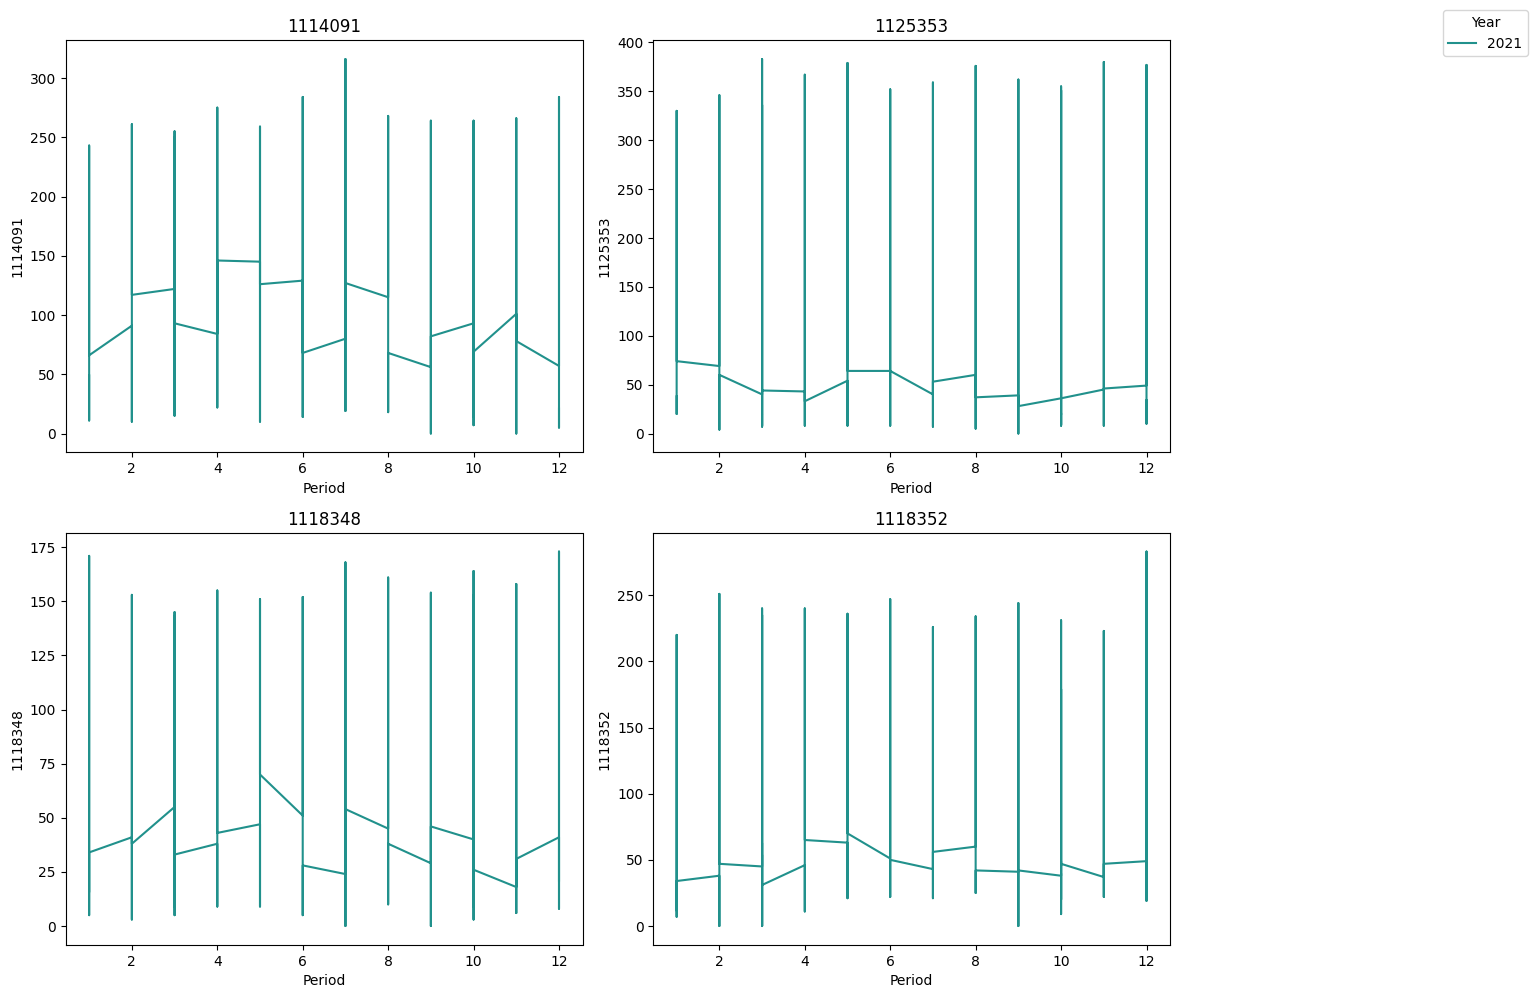

In [21]:
plot_seasonal_trends_with_legends(gla_his, ['1114091', '1125353', '1118348', '1118352'], layout=(2, 2), period='Month', cmap='viridis')


In [24]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 81.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_2439935/1700098453.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sm.graphics.tsa.plot_acf(data[col].resample('1D').mean().fillna(method='ffill'), ax=ax, lags=14, alpha=0.05, title=f'Autocorrelation for {col}')


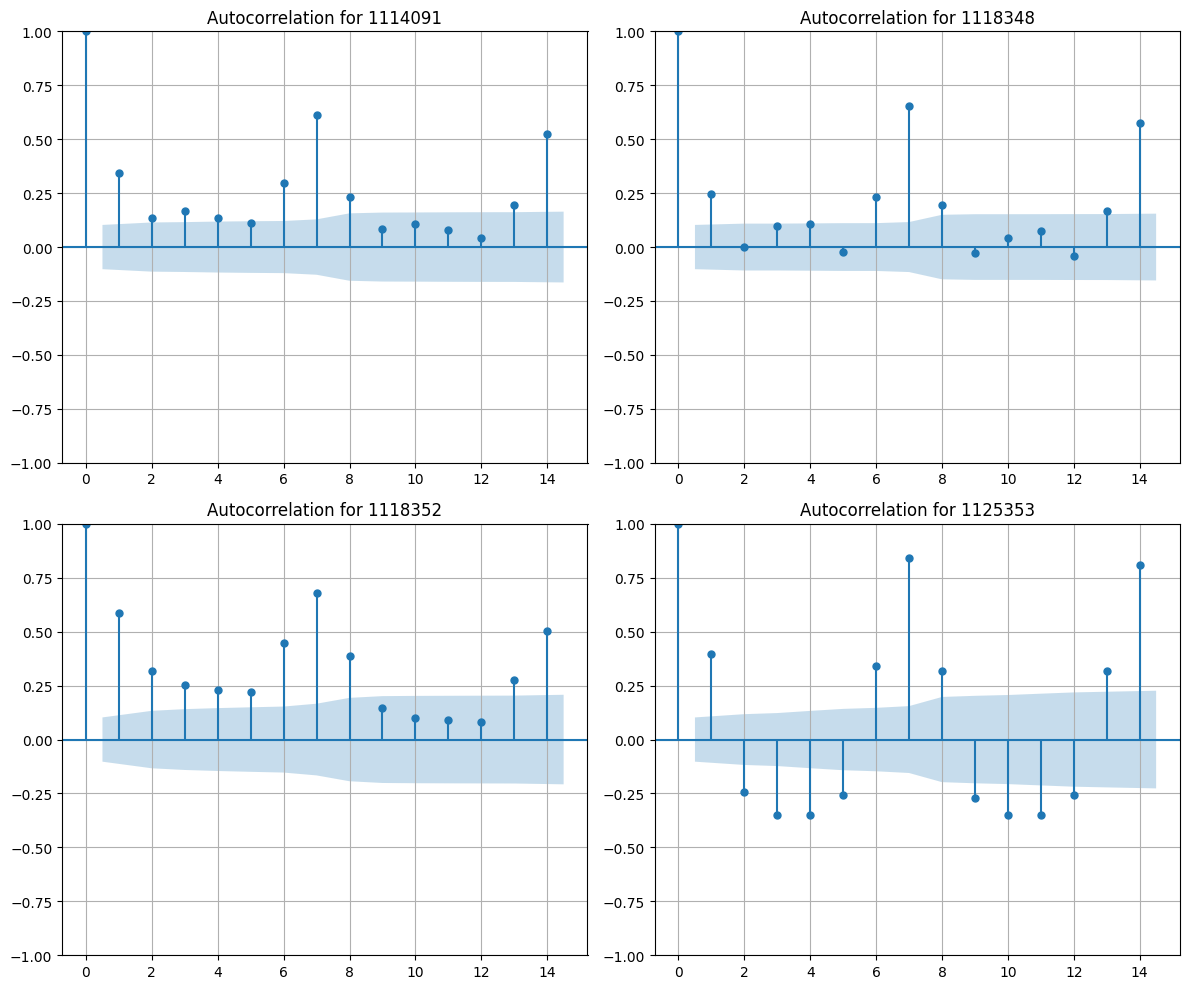

/tmp/ipykernel_2439935/1700098453.py:47: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sm.graphics.tsa.plot_acf(data[col].resample('1H').mean().fillna(method='ffill'), ax=ax, lags=48, alpha=0.05, title=f'Autocorrelation for {col}')


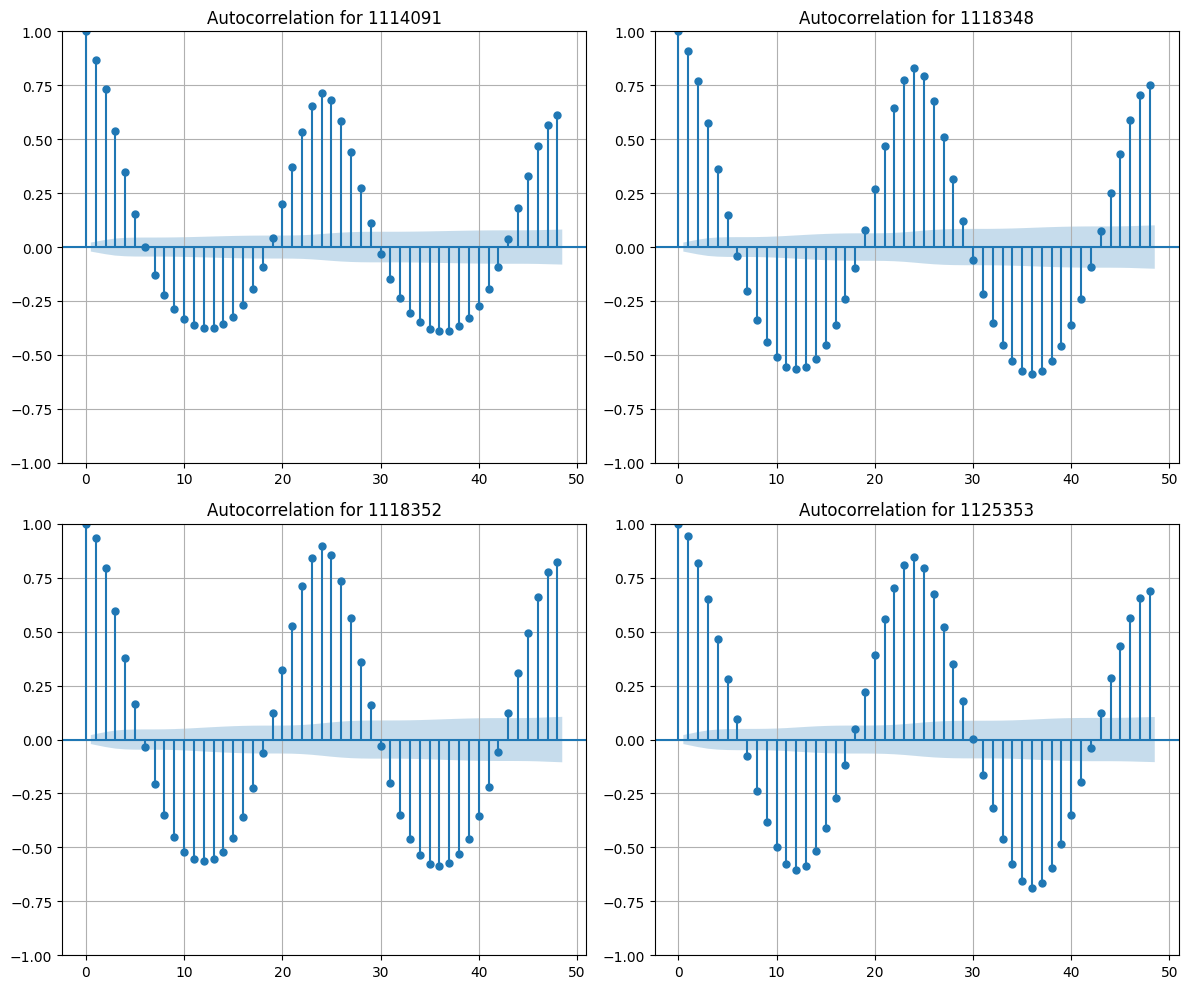

/tmp/ipykernel_2439935/1700098453.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sm.graphics.tsa.plot_acf(data[col].fillna(method='ffill'), ax=ax, lags=40, alpha=0.05, title=f'Autocorrelation for {col}')


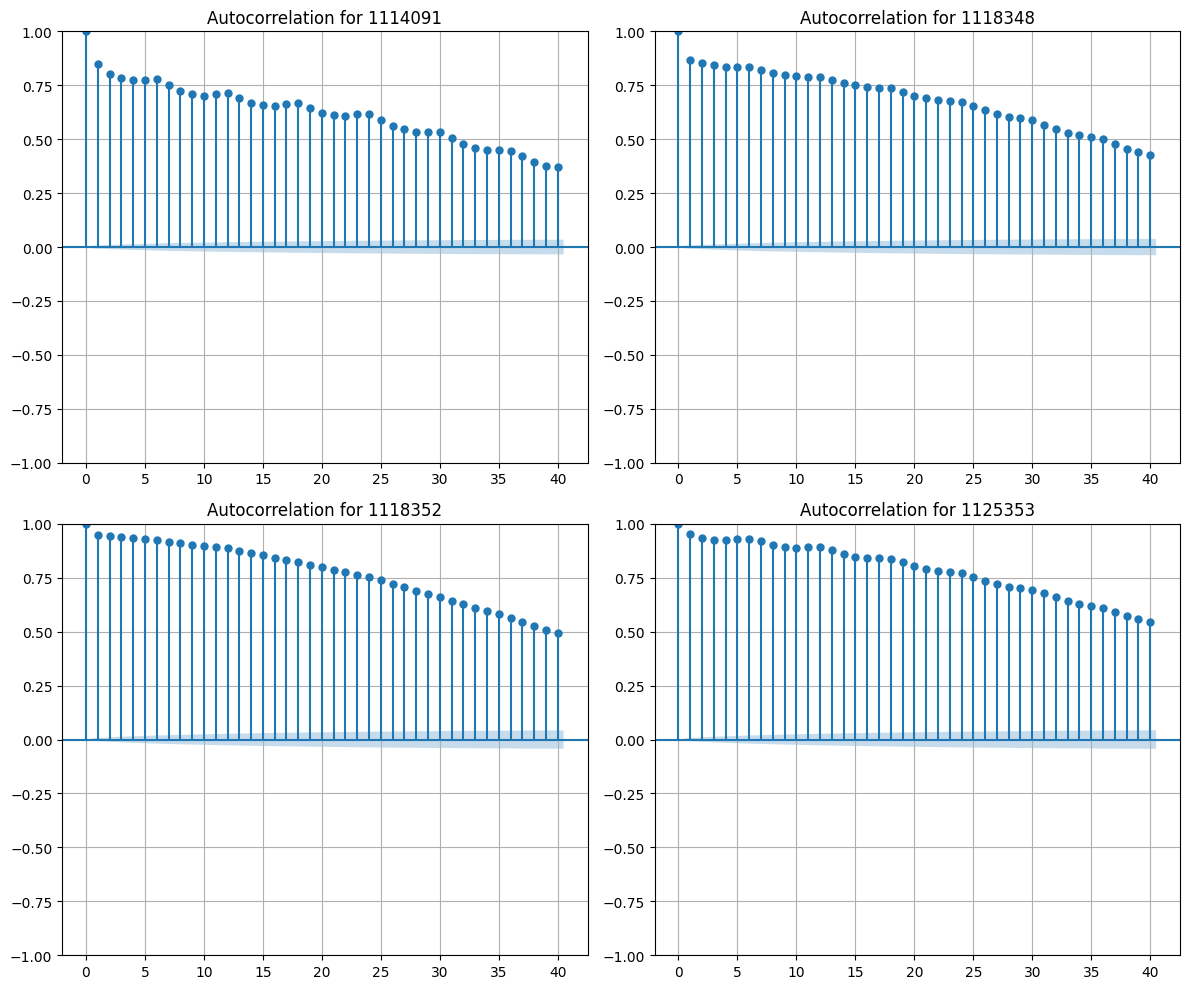

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the dataset
data = gla_his[['1114091', '1125353', '1118348', '1118352']]


# Get all column names except for 'date'
columns = data.columns.difference(['date'])

# Calculate the number of rows, two plots per row
rows = len(columns) // 2 + (len(columns) % 2)

# Create the canvas, two autocorrelation plots per row
fig, axs = plt.subplots(rows, 2, figsize=(12, 5*rows))

# Ensure axs is two-dimensional for easy indexing
if rows == 1:
    axs = axs.reshape(1, -1)

# Plot the autocorrelation for each variable
for i, col in enumerate(columns):
    ax = axs[i // 2, i % 2]
    sm.graphics.tsa.plot_acf(data[col].resample('1D').mean().fillna(method='ffill'), ax=ax, lags=14, alpha=0.05, title=f'Autocorrelation for {col}')
    ax.set_ylim(-1, 1)
    ax.grid(True)

# If the number of columns is odd, remove the last, unneeded subplot
if len(columns) % 2:
    fig.delaxes(axs[-1, -1])

# Adjust the layout
plt.tight_layout()
plt.show()

# Create the canvas, two autocorrelation plots per row
fig, axs = plt.subplots(rows, 2, figsize=(12, 5*rows))

# Ensure axs is two-dimensional for easy indexing
if rows == 1:
    axs = axs.reshape(1, -1)

# Plot the autocorrelation for each variable
for i, col in enumerate(columns):
    ax = axs[i // 2, i % 2]
    sm.graphics.tsa.plot_acf(data[col].resample('1H').mean().fillna(method='ffill'), ax=ax, lags=48, alpha=0.05, title=f'Autocorrelation for {col}')
    ax.set_ylim(-1, 1)
    ax.grid(True)

# If the number of columns is odd, remove the last, unneeded subplot
if len(columns) % 2:
    fig.delaxes(axs[-1, -1])

# Adjust the layout
plt.tight_layout()
plt.show()

# Create the canvas, two autocorrelation plots per row
fig, axs = plt.subplots(rows, 2, figsize=(12, 5*rows))

# Ensure axs is two-dimensional for easy indexing
if rows == 1:
    axs = axs.reshape(1, -1)

# Plot the autocorrelation for each variable
for i, col in enumerate(columns):
    ax = axs[i // 2, i % 2]
    sm.graphics.tsa.plot_acf(data[col].fillna(method='ffill'), ax=ax, lags=40, alpha=0.05, title=f'Autocorrelation for {col}')
    ax.set_ylim(-1, 1)
    ax.grid(True)

# If the number of columns is odd, remove the last, unneeded subplot
if len(columns) % 2:
    fig.delaxes(axs[-1, -1])

# Adjust the layout
plt.tight_layout()
plt.show()

In [37]:
data[col].resample('1H').mean()

Time
2021-01-01 00:00:00    31.416667
2021-01-01 01:00:00    32.500000
2021-01-01 02:00:00    26.750000
2021-01-01 03:00:00    25.000000
2021-01-01 04:00:00    25.916667
                         ...    
2021-12-31 19:00:00    57.500000
2021-12-31 20:00:00    47.250000
2021-12-31 21:00:00    36.833333
2021-12-31 22:00:00    37.500000
2021-12-31 23:00:00    38.166667
Freq: H, Name: 1125353, Length: 8760, dtype: float64

In [38]:
def plot_seasonal_trends_with_legends(df, columns, layout=(3, 2), period='DayOfMonth', resample_freq=None, cmap='viridis'):
    """
    Plots one or more seasonal trend graphs showing monthly patterns, with optional resampling.
    
    Parameters:
    - df: A pandas DataFrame containing the time series data, with a DatetimeIndex.
    - columns: A single column name or a list of column names to plot.
    - layout: Layout of subplots, format as (rows, cols).
    - period: Period feature for x-axis, can be 'DayOfMonth', 'HourOfDay', or 'DayOfWeek'.
    - resample_freq: Resampling frequency (e.g., '15T' for 15min, '1H' for hourly, '1D' for daily). None for no resampling.
    - cmap: Name of the colormap scheme.
    """
    # Resample if specified
    if resample_freq is not None:
        df = df.resample(resample_freq).mean()
    
    # Ensure columns are in list form, even if it's just one column
    if isinstance(columns, str):
        columns = [columns]
    
    # Add columns for month and the selected period
    df = df.copy()
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    
    if period == 'DayOfMonth':
        df['Period'] = df.index.day
        period_label = 'Day of Month'
    elif period == 'HourOfDay':
        df['Period'] = df.index.hour
        period_label = 'Hour of Day'
    elif period == 'DayOfWeek':
        df['Period'] = df.index.dayofweek
        period_label = 'Day of Week (0=Mon, 6=Sun)'
    elif period == 'DayOfYear':
        df['Period'] = df.index.dayofyear
        period_label = 'Day of Year'
    else:
        raise ValueError(f"Unsupported period '{period}'. Choose from 'DayOfMonth', 'HourOfDay', 'DayOfWeek', or 'DayOfYear'.")

    rows, cols = layout
    fig, axs = plt.subplots(rows, cols, figsize=(cols*7, rows*5))
    
    # Wrap axs in a list if it's a single subplot
    if not isinstance(axs, np.ndarray):
        axs = [axs]
    else:
        axs = axs.flatten()  # Flatten the array for easy iteration

    for i, column in enumerate(columns):
        if i < len(axs):  # Only plot if there are enough subplots
            ax = axs[i]
            months = sorted(df['Month'].unique())
            color_palette = sns.color_palette(cmap, n_colors=len(months))
            month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
            
            for j, month in enumerate(months):
                monthly_data = df[df['Month'] == month]
                ax.plot(monthly_data['Period'], monthly_data[column], 
                       label=month_names[month-1], color=color_palette[j], alpha=0.7)

            ax.set_title(f'{column}')
            ax.set_xlabel(period_label)
            ax.set_ylabel(column)
            ax.grid(True, alpha=0.3)
        else:
            break  # Stop plotting if there are more columns than subplots

    # Hide any excess subplots
    for i in range(len(columns), len(axs)):
        axs[i].axis('off')
    
    # Place the legend to the right of the last subplot
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title='Month')

    resample_note = f" (Resampled: {resample_freq})" if resample_freq else ""
    fig.suptitle(f'Seasonal Patterns by Month{resample_note}', fontsize=14, y=1.02)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

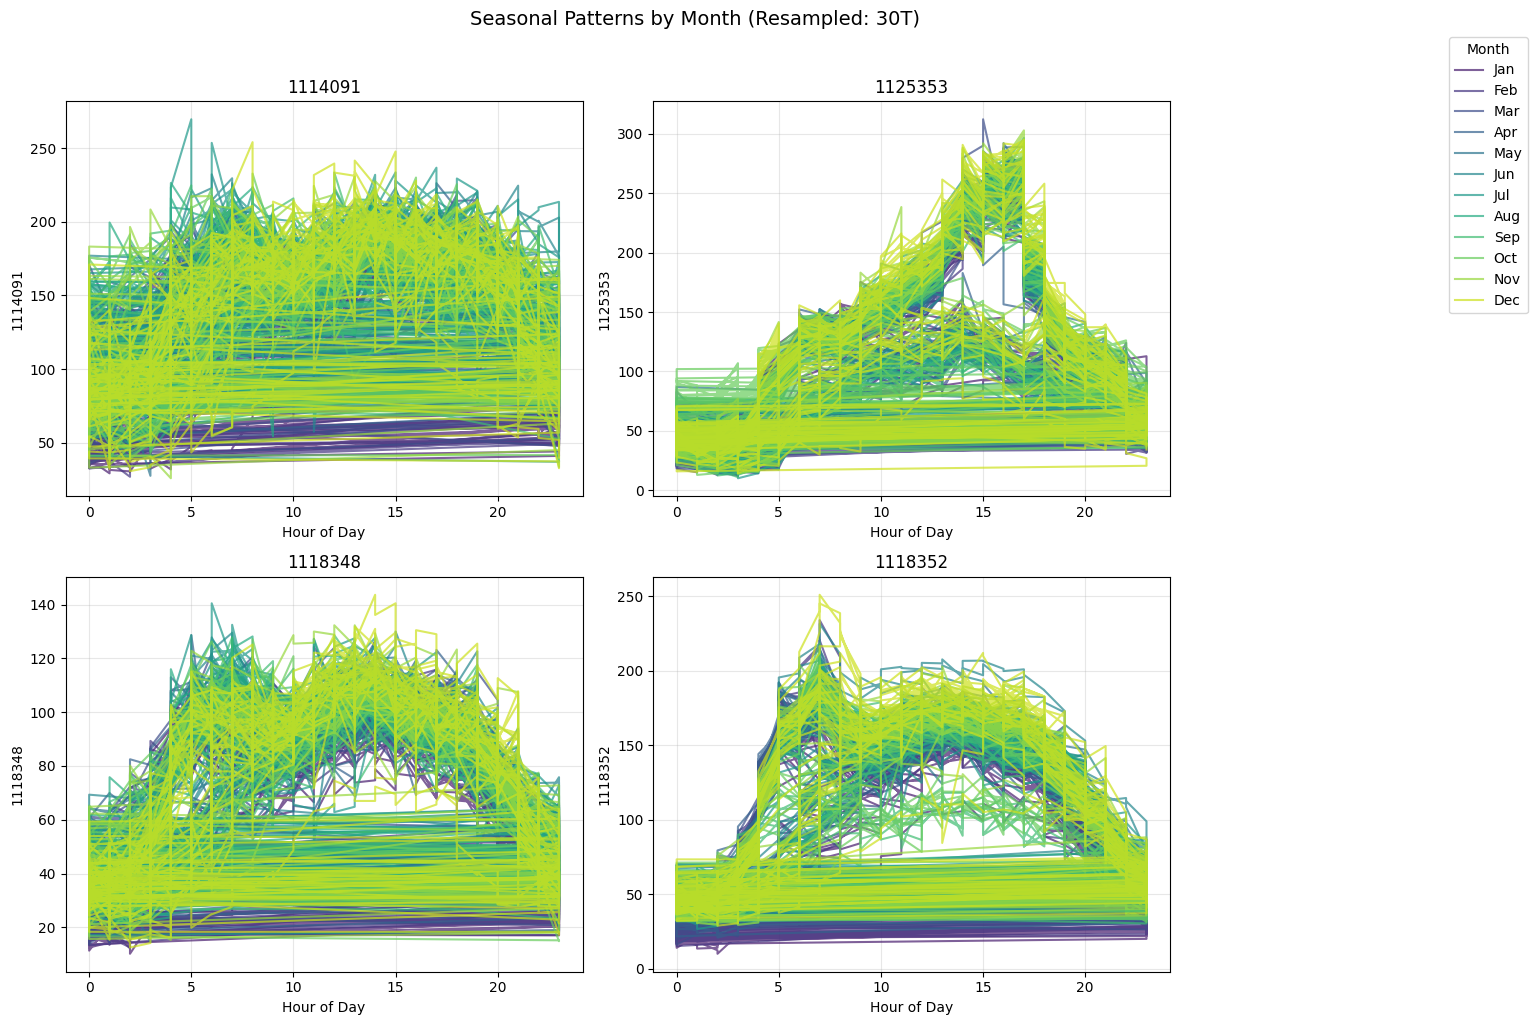

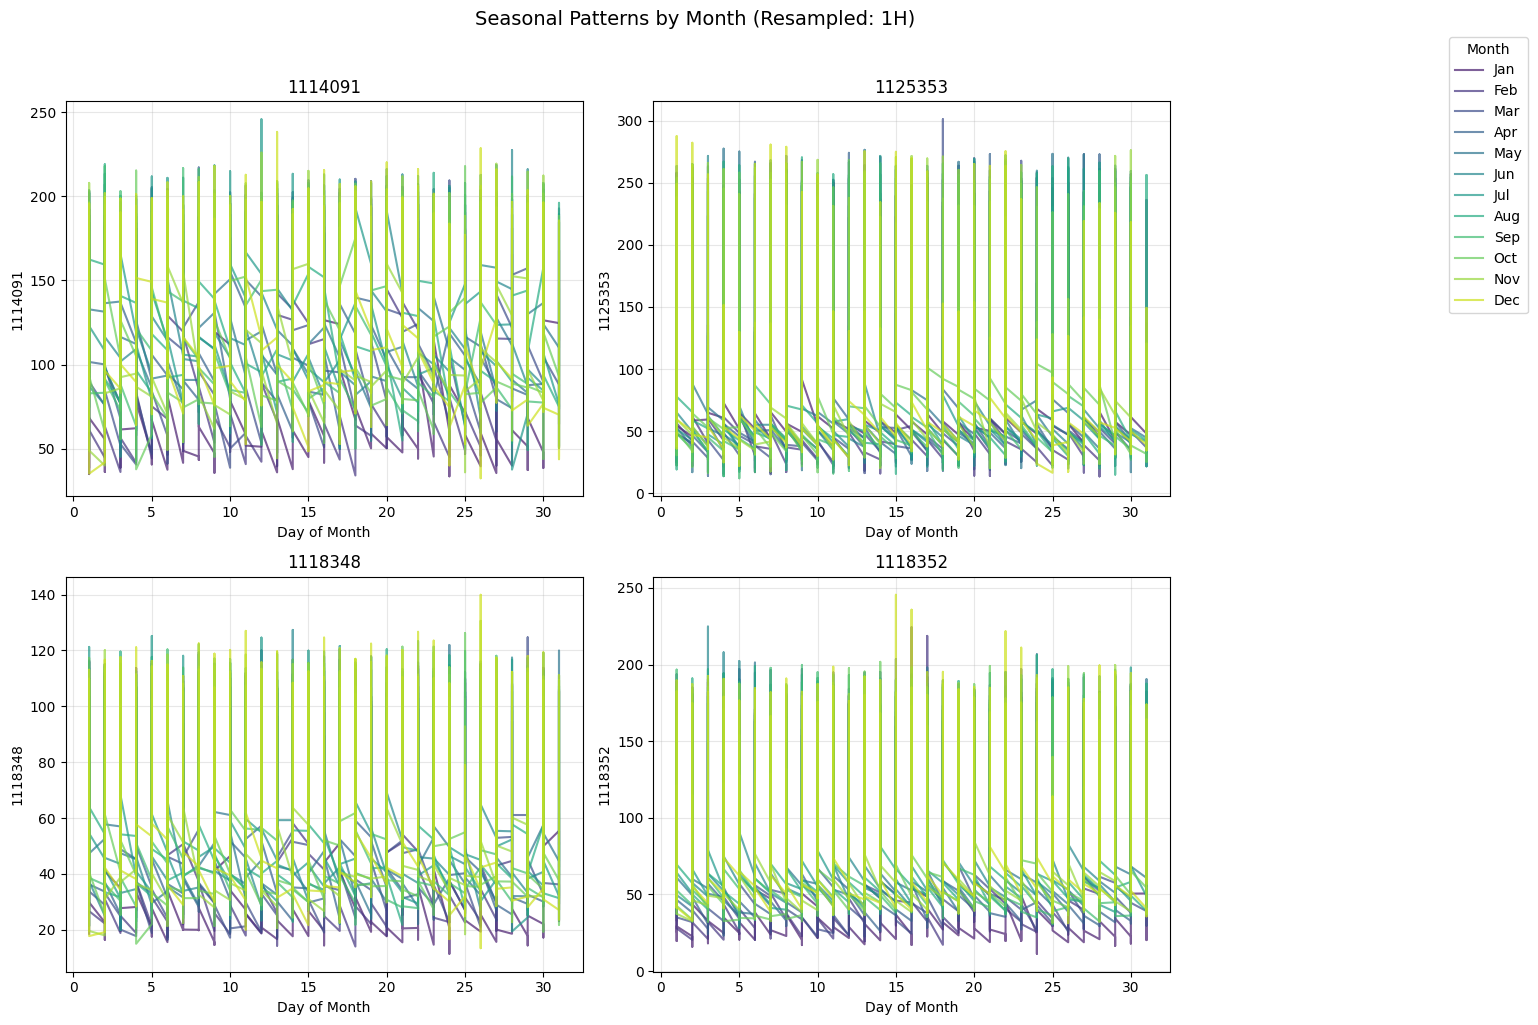

In [27]:
# 30-minute resampling, show daily patterns for each month
plot_seasonal_trends_with_legends(gla_his, ['1114091', '1125353', '1118348', '1118352'], layout=(2, 2), 
                                  period='HourOfDay', resample_freq='30T')

# Hourly resampling, show day-of-month patterns
plot_seasonal_trends_with_legends(gla_his, ['1114091', '1125353', '1118348', '1118352'], layout=(2, 2), 
                                  period='DayOfMonth', resample_freq='1H')

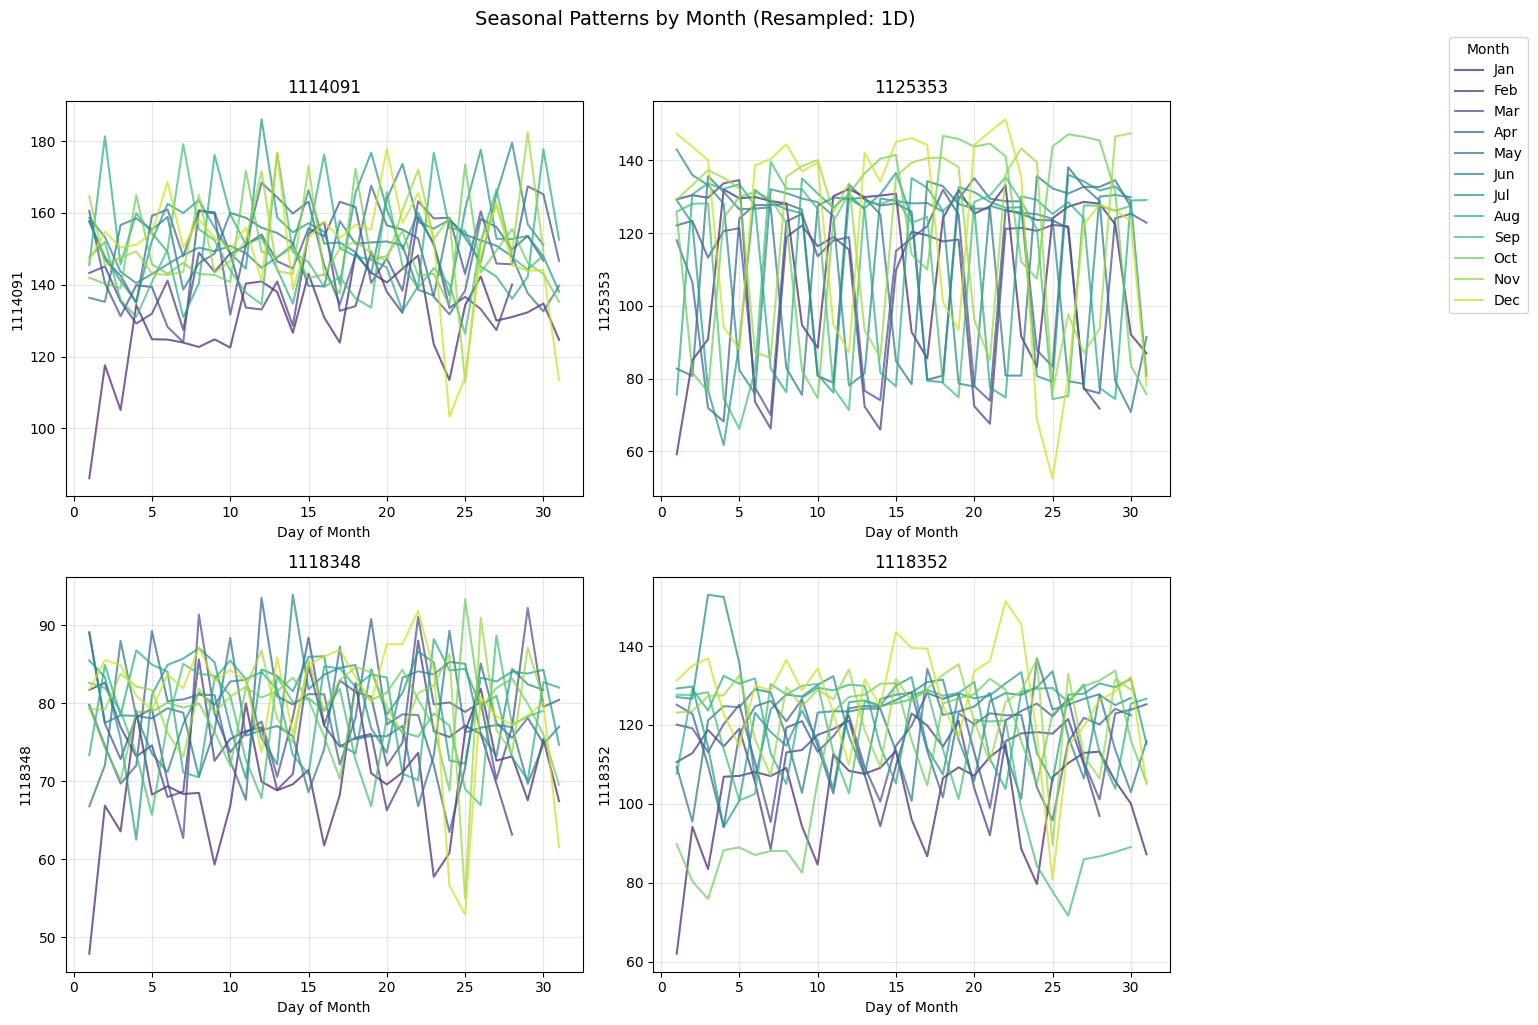

In [30]:
plot_seasonal_trends_with_legends(gla_his, ['1114091', '1125353', '1118348', '1118352'], 
                                  layout=(2, 2), 
                                  period='DayOfMonth', 
                                  resample_freq='1D')  # Daily resampling